# 04B — Threshold Sensitivity on Monthly Coverage-Masked Grids (Checkpoint 4B)

Methodological question: **how much do the estimated center, area, and intensity of the candidate
high-flux region change when it is defined with different flux thresholds?**

Operates ONLY on the accepted CP4A monthly grid tables (NOAA-19, Jan 2024, `mep_omni_flux_p1`),
using ONLY cells passing the CP4A coverage masks. **Executed on real data — outputs are real.**

> **Cautious language.** These are *candidate high-flux regions* / *threshold-defined footprints*
> with *method-dependent centers* and *area proxies* — an *exploratory monthly analysis*. **Not** a
> true SAA boundary, danger zone, radiation dose, health risk, or discovery. `mep_IFC_on == -1` was
> retained in CP4A and **remains uninterpreted**; this checkpoint does not resolve it.

In [1]:
import os, sys, pathlib
import numpy as np, pandas as pd
from IPython.display import display
import matplotlib.pyplot as plt

cwd = pathlib.Path.cwd()
ROOT = cwd.parent if cwd.name == "notebooks" else cwd
sys.path.insert(0, str(ROOT / "src"))

from saa.threshold_analysis import (
    run_sensitivity, save_sensitivity, haversine_km, coverage_passed,
    plot_threshold_overlay, plot_centroid_shift,
)

TBL = ROOT / "outputs" / "tables"
FIG = ROOT / "outputs" / "figures"
T5 = TBL / "cp4a_noaa19_2024-01_grid_5deg.parquet"
T2 = TBL / "cp4a_noaa19_2024-01_grid_2deg.parquet"
t5 = pd.read_parquet(T5)
t2 = pd.read_parquet(T2)
print("loaded CP4A grid tables: 5deg", t5.shape, "| 2deg", t2.shape)

loaded CP4A grid tables: 5deg (432, 9) | 2deg (2700, 9)


## Step 1 — Coverage-passed cells (CP4A masks; failed cells excluded)

In [2]:
c5 = coverage_passed(t5, "enough_samples_5deg")
c2 = coverage_passed(t2, "enough_samples_2deg")
print("5deg coverage-passed cells:", len(c5), "/", len(t5))
print("2deg coverage-passed cells:", len(c2), "/", len(t2))

5deg coverage-passed cells: 432 / 432
2deg coverage-passed cells: 2685 / 2700


## Step 2 — Threshold sweep (percentile cutoffs 80/90/95/98/99 = top 20/10/5/2/1%)

For 5deg & 2deg x mean_flux & median_flux. Area uses the spherical-cap approximation
(`R^2 * dlon_rad * (sin(lat_N) - sin(lat_S))`, R=6371 km) — never raw cell count.

In [3]:
grids = [(5, 5.0, t5, "enough_samples_5deg"), (2, 2.0, t2, "enough_samples_2deg")]
sens = run_sensitivity(grids)
print("sensitivity rows:", len(sens), "(expect 20)")

CSV = TBL / "cp4b_threshold_sensitivity.csv"
PARQ = TBL / "cp4b_threshold_sensitivity.parquet"
save_sensitivity(sens, CSV, PARQ)
print("saved:", CSV.name, "+", PARQ.name)

display(sens[["grid_deg", "statistic_used", "threshold_label", "flux_cutoff_value",
              "selected_cell_count", "selected_area_km2", "selected_area_fraction_of_covered_region",
              "centroid_lat_flux_weighted", "centroid_lon_flux_weighted", "peak_flux"]].round(3))

sensitivity rows: 20 (expect 20)
saved: cp4b_threshold_sensitivity.csv + cp4b_threshold_sensitivity.parquet


,grid_deg,statistic_used,threshold_label,flux_cutoff_value,selected_cell_count,selected_area_km2,selected_area_fraction_of_covered_region,centroid_lat_flux_weighted,centroid_lon_flux_weighted,peak_flux
0,5,mean_flux,top20,5.139,87,2.499791e+07,0.229,-20.169,-55.266,31.462
1,5,mean_flux,top10,12.564,44,1.261403e+07,0.116,-21.154,-55.635,31.462
2,5,mean_flux,top5,19.763,22,6.309309e+06,0.058,-21.575,-55.757,31.462
3,5,mean_flux,top2,26.290,9,2.574264e+06,0.024,-22.031,-55.321,31.462
4,5,mean_flux,top1,28.690,5,1.416046e+06,0.013,-23.457,-56.471,31.462
5,5,median_flux,top20,4.880,87,2.498443e+07,0.229,-20.160,-55.023,31.516
6,5,median_flux,top10,12.767,44,1.261403e+07,0.116,-21.126,-55.614,31.516
7,5,median_flux,top5,19.848,22,6.309309e+06,0.058,-21.542,-55.890,31.516
8,5,median_flux,top2,26.365,9,2.574264e+06,0.024,-22.006,-55.312,31.516
9,5,median_flux,top1,28.776,5,1.416046e+06,0.013,-23.458,-55.553,31.516


## Step 3 — Key sensitivity summary

In [4]:
print("CENTROID SHIFT  top20 -> top1  (flux-weighted):")
for g in (5, 2):
    for st in ("mean_flux", "median_flux"):
        s = sens[(sens.grid_deg == g) & (sens.statistic_used == st)].set_index("threshold_label")
        a, b = s.loc["top20"], s.loc["top1"]
        d = haversine_km(a.centroid_lat_flux_weighted, a.centroid_lon_flux_weighted,
                         b.centroid_lat_flux_weighted, b.centroid_lon_flux_weighted)
        print("  %ddeg %-11s shift=%4.0f km | area x%.3f (%.1f%% -> %.1f%% of covered region)"
              % (g, st, d, b.selected_area_km2 / a.selected_area_km2,
                 100 * a.selected_area_fraction_of_covered_region,
                 100 * b.selected_area_fraction_of_covered_region))

print()
print("MEAN vs MEDIAN center distance (top10, flux-weighted):")
for g in (5, 2):
    mm = sens[(sens.grid_deg == g) & (sens.threshold_label == "top10")].set_index("statistic_used")
    d = haversine_km(mm.loc["mean_flux"].centroid_lat_flux_weighted, mm.loc["mean_flux"].centroid_lon_flux_weighted,
                     mm.loc["median_flux"].centroid_lat_flux_weighted, mm.loc["median_flux"].centroid_lon_flux_weighted)
    print("  %ddeg: %.0f km" % (g, d))

print()
a = sens[(sens.grid_deg == 5) & (sens.threshold_label == "top10") & (sens.statistic_used == "mean_flux")].iloc[0]
b = sens[(sens.grid_deg == 2) & (sens.threshold_label == "top10") & (sens.statistic_used == "mean_flux")].iloc[0]
print("5deg vs 2deg center distance (top10 mean, flux-weighted): %.0f km" % haversine_km(
    a.centroid_lat_flux_weighted, a.centroid_lon_flux_weighted,
    b.centroid_lat_flux_weighted, b.centroid_lon_flux_weighted))

CENTROID SHIFT  top20 -> top1  (flux-weighted):
  5deg mean_flux   shift= 386 km | area x0.057 (22.9% -> 1.3% of covered region)


  5deg median_flux shift= 371 km | area x0.057 (22.9% -> 1.3% of covered region)
  2deg mean_flux   shift= 343 km | area x0.050 (22.8% -> 1.1% of covered region)
  2deg median_flux shift= 307 km | area x0.059 (22.8% -> 1.3% of covered region)

MEAN vs MEDIAN center distance (top10, flux-weighted):
  5deg: 4 km
  2deg: 11 km

5deg vs 2deg center distance (top10 mean, flux-weighted): 32 km


## Step 4 — Figures: threshold overlays + centroid-shift path

Overlays show the coverage-masked monthly flux map (grey, log10) with nested open-circle markers for
each top-X% set and an `x` at each set's flux-weighted centroid. Coverage-failed cells are blank.
No smoothing, no interpolation.

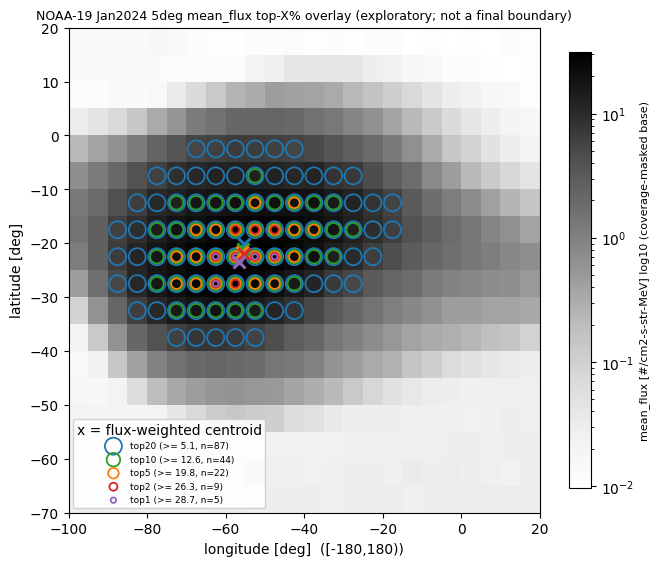

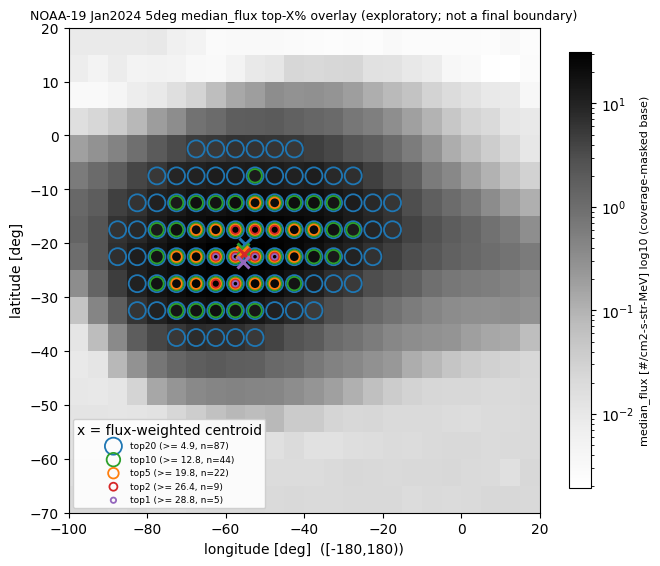

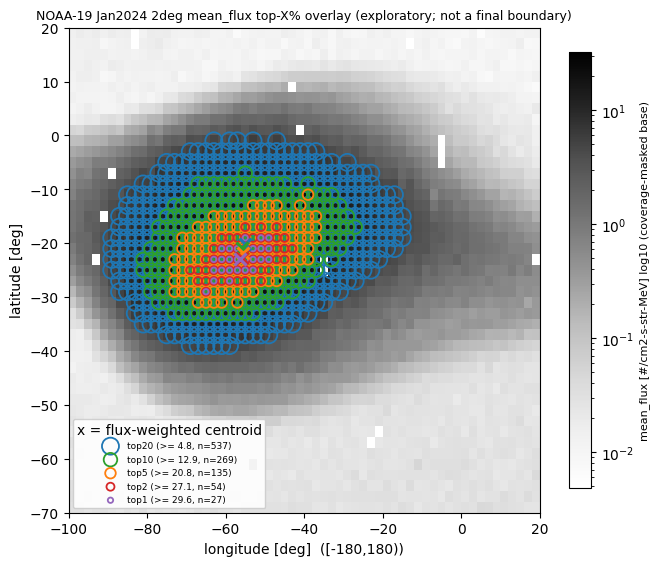

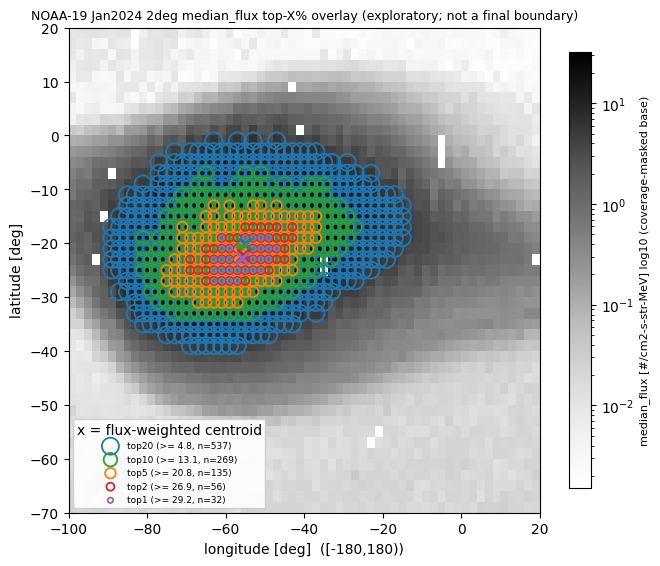

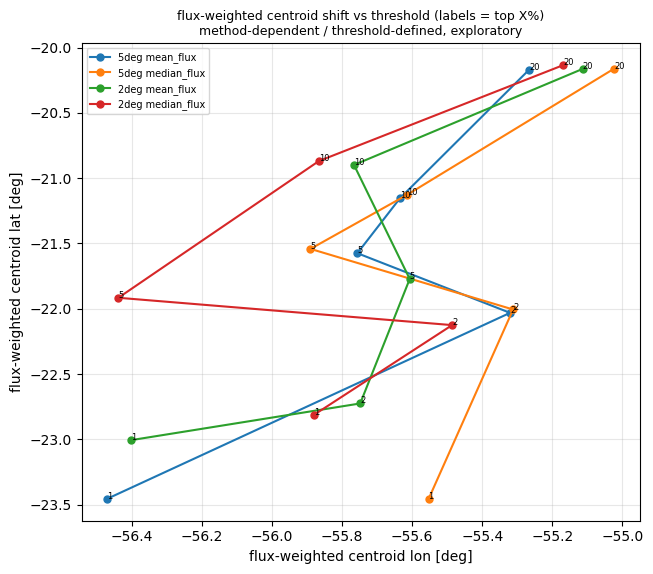

saved 5 figures to /home/fellipe/Projects/Active/saa-poes-mapping/outputs/figures


In [5]:
specs = [
    (t5, "mean_flux",   5.0, "enough_samples_5deg", "cp4b_threshold_overlay_5deg_mean.png",   "5deg mean_flux"),
    (t5, "median_flux", 5.0, "enough_samples_5deg", "cp4b_threshold_overlay_5deg_median.png", "5deg median_flux"),
    (t2, "mean_flux",   2.0, "enough_samples_2deg", "cp4b_threshold_overlay_2deg_mean.png",   "2deg mean_flux"),
    (t2, "median_flux", 2.0, "enough_samples_2deg", "cp4b_threshold_overlay_2deg_median.png", "2deg median_flux"),
]
for table, stat, step, mask, fname, label in specs:
    plot_threshold_overlay(table, stat, step, mask, str(FIG / fname),
                           "NOAA-19 Jan2024 %s top-X%% overlay (exploratory; not a final boundary)" % label)

plot_centroid_shift(sens, str(FIG / "cp4b_centroid_shift_by_threshold.png"))
plt.show()
print("saved 5 figures to", FIG)

## Summary (exploratory)

Threshold sensitivity quantified for the candidate high-flux region: as the threshold tightens
(top 20% -> top 1%), the **threshold-defined footprint** shrinks and its **flux-weighted center**
shifts by a few hundred km, while mean vs median and 5deg vs 2deg give nearly the same centers.
These are **method-dependent objects** and **area proxies** for an **exploratory monthly analysis** —
**not** a true SAA boundary, dose, health risk, or discovery. Validate with
`python scripts/validate_cp4b_outputs.py`.

Next (Checkpoint 4C+): extend sensitivity to channel / satellite / time-window axes, and only then
consider magnetic-coordinate (IGRF) framing.